# Grid Generation Notebook

This Notebook is used in order to generate a grid of values that SEM2DPACK will use as input parameter

## Import Data

### 1) Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata, LinearNDInterpolator
import sys
import os
sys.path.append(os.getcwd()+'/../../modules/')
from Stage_module import *

### 2) Import the grid of nodes

In [2]:
def read_grid(filepath):
    values = pd.read_csv(filepath, header=None).to_numpy()
    grid = np.array([])
    for i, line in enumerate(values):
        val = np.array(line[0].split(),dtype=float)
        if i%2==0:
            line_values = np.array([])
            line_values = np.concatenate([line_values, val], axis=0)
        else:
            line_values = np.concatenate([line_values, val], axis=0)
            if i==1:
                grid = np.concatenate([grid,line_values], axis=0)
            else:
                grid = np.vstack([grid,line_values])
    return grid

grid = read_grid('USER_2D_grid.inp')
e, ii, jj, X_SEM, Z_SEM = grid[:,0].astype(int), grid[:,1].astype(int), grid[:,2].astype(int), grid[:,3], grid[:,4]

## Generate a stochastic distribution

### 1) Define functions

In [3]:
def compute_spatial_frequencies(Lx, Lz, Nx, Nz):
    """ 
    Function which compute the spatial frequencies of a grid

    Parameters :
    Lx, Lz : Domain lengths
    Nx, Nz : Number of points int the domain
    """
    kx = 2*np.pi*np.fft.fftfreq(Nx, Lx/Nx)
    kz = 2*np.pi*np.fft.fftfreq(Nz, Lz/Nz)
    return kx, kz

def compute_Von_Karman_SPD(kx, kz, Lc_x, Lc_z, nu=1):
    """
    Function which compute the Spectral Power Density of a Von Karman distribution

    Parameters :
    kx, kz : Spatial frequencies (1D array)
    Lc_x, Lc_z : Typical length of variation (float)
    nu : Roughness parameter
    """
    Kx, Kz = np.meshgrid(kx,kz)
    kc_x = 1/Lc_x
    kc_z = 1/Lc_z
    S = 1 / (1 + (Kx/kc_x)**2 + (Kz/kc_z)**2)**(nu+1)
    return S

def compute_field(SPD):
    """
    Function which compute the field associated to a particular Spectral Power Density

    Parameters :
    SPD : Spectral Power Density (2D array)
    """
    W = np.random.normal(loc=0.0, scale=1.0, size=SPD.shape) #Compute a Gaussian White Field
    root = np.sqrt(SPD)
    G = np.fft.ifft2( root * np.fft.fft2(W) )
    return np.abs(G)

### 2) Compute a stochastic grid

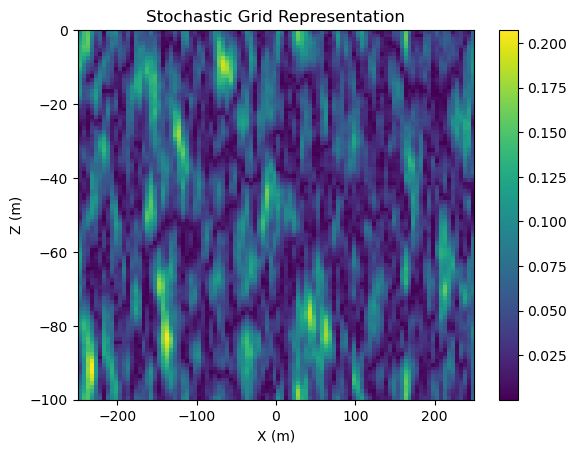

In [ ]:
#----------- PARAMETERS -------------
# Domain parameters
xmin = -250
xmax = 250
zmin = -100
zmax = 0
Lx = xmax - xmin
Lz = zmax - zmin
Nx = 100
Nz = 100

# Distribution parameters
sigma = 1
Lc_x = 10
Lc_z = 10
nu = 1

#Changer seulement Lc_x
#------------------------------------

# Computations
X = np.linspace(xmin, xmax, Nx)
Z = np.linspace(zmin, zmax, Nz)
kx, kz = compute_spatial_frequencies(Lx, Lz, Nx, Nz)
S = compute_Von_Karman_SPD(kx, kz, Lc_x, Lc_z, nu=nu)
G = compute_field(S)

# Plotting
fig, ax = plt.subplots()
im = ax.imshow(G, extent=[xmin, xmax, zmin, zmax])
plt.colorbar(im, ax=ax, cmap='viridis_r')
ax.set_title("Stochastic Grid Representation")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect('auto')
plt.show()

### 3) Compute all fields based on the distribution

In [ ]:
#----- S-Wave Velocities -------
Vs_min = 250
Vs_max = 2000
Vs = np.interp(G, (np.min(G), np.max(G)), (Vs_min, Vs_max))

#----- P-Wave Velocities -------
nu = 0.3
coeff = np.sqrt(2*(1-nu)/(1-2*nu))
Vp_min = Vs_min*coeff
Vp_max = Vs_max*coeff
Vp = np.interp(G, (np.min(G), np.max(G)), (Vp_min, Vp_max))

#----- Densities -------
rho_min = 1500
rho_max = 3000
#rho = np.interp(G, (np.min(G), np.max(G)), (rho_min, rho_max))
rho = 2000*np.ones(Vs.shape)

## Interpolate the fields on SEM2DPACK's nodes

### 1) Create masks and define structure properties

In [6]:
# Masks
soil_mask = (Z_SEM <= 0)
structure_mask = (np.abs(Z_SEM) < 30) & (np.abs(X_SEM) < 10)

# Structure properties
Vs_struct = 300
Vp_struct = Vs_struct*coeff
rho_struct = 2000

### 2) Interpolate data on the grid

In [7]:
# Variables definition
X_stoch, Z_stoch = np.meshgrid(X,Z)
Vs_SEM = np.zeros(X_SEM.size)
Vp_SEM = np.zeros(X_SEM.size)
rho_SEM = np.zeros(X_SEM.size)

# Interpolation and mask applications
Vs_SEM[soil_mask] = griddata((X_stoch.flatten(), Z_stoch.flatten()), Vs.flatten(), (X_SEM[soil_mask],Z_SEM[soil_mask]), method='linear', fill_value=0)
Vs_SEM[structure_mask] = Vs_struct

Vp_SEM[soil_mask] = griddata((X_stoch.flatten(), Z_stoch.flatten()), Vp.flatten(), (X_SEM[soil_mask],Z_SEM[soil_mask]), method='linear', fill_value=0)
Vp_SEM[structure_mask] = Vp_struct

rho_SEM[soil_mask] = griddata((X_stoch.flatten(), Z_stoch.flatten()), rho.flatten(), (X_SEM[soil_mask],Z_SEM[soil_mask]), method='linear', fill_value=0)
rho_SEM[structure_mask] = rho_struct


## Export data

In [8]:
file = open(os.getcwd()+'/USER_2D_grid_values.inp', 'w+')
for i in range(X_SEM.size):
    if i==X_SEM.size-1:
        file.write(f"{e[i]:12d}{ii[i]:12d}{jj[i]:12d}{Vs_SEM[i]:12.5f}{Vp_SEM[i]:12.5f}\n")
    else:
        file.write(f"{e[i]:12d}{ii[i]:12d}{jj[i]:12d}{Vs_SEM[i]:12.5f}{Vp_SEM[i]:12.5f}\n")
file.close()